# Weather prediction

## Predict Weather using precipation, maximum temperature, minimum temperature, wind features

### Without oversampling of classes

Classification Report:

              precision    recall  f1-score   support

     drizzle       0.12      0.09      0.11        11
         fog       0.33      0.10      0.15        20
        rain       0.98      0.92      0.95       129
        snow       0.80      0.80      0.80         5
         sun       0.78      0.93      0.85       128

    accuracy                           0.84       293
   macro avg       0.60      0.57      0.57       293
weighted avg       0.81      0.84      0.82       293



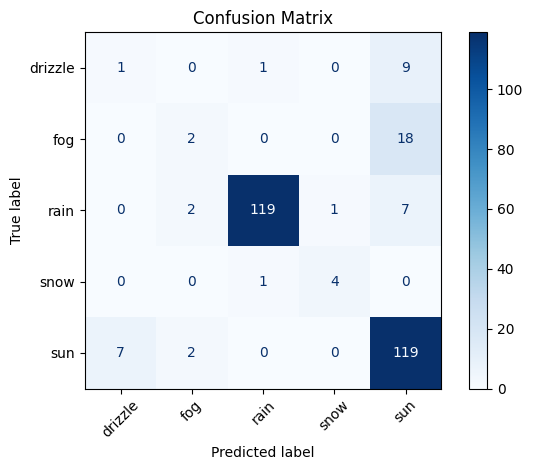


Predicted weather for new day: drizzle


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE  # Uncomment if using SMOTE

# 1. Load the dataset
df = pd.read_csv('seattle-weather.csv')

# 2. Encode weather labels into numeric form
le = LabelEncoder()
df['weather_label'] = le.fit_transform(df['weather'])

# 3. Select features and target
X = df[['precipitation', 'temp_max', 'temp_min', 'wind']]
y = df['weather_label']

# # Optional: Handle class imbalance with SMOTE
# smote = SMOTE(random_state=None)
# X, y = smote.fit_resample(X, y)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=None, stratify=y
)

# 5. Train the Random Forest Classifier with class_weight
clf = RandomForestClassifier(n_estimators=100, random_state=None, class_weight='balanced')
clf.fit(X_train, y_train)

# 6. Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# 7. Confusion matrix plot
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=le.classes_, cmap='Blues', xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Predict on a new sample
new_day_df = pd.DataFrame(np.array([[0, 12.8, 5, 4.7]]),
                          columns=['precipitation', 'temp_max', 'temp_min', 'wind'])

predicted = clf.predict(new_day_df)
print("\nPredicted weather for new day:", le.inverse_transform(predicted)[0])

### With oversampling of classes

Classification Report:

              precision    recall  f1-score   support

     drizzle       0.83      0.79      0.81       128
         fog       0.80      0.83      0.82       128
        rain       0.99      0.87      0.93       129
        snow       0.96      1.00      0.98       128
         sun       0.71      0.78      0.75       128

    accuracy                           0.85       641
   macro avg       0.86      0.85      0.85       641
weighted avg       0.86      0.85      0.85       641



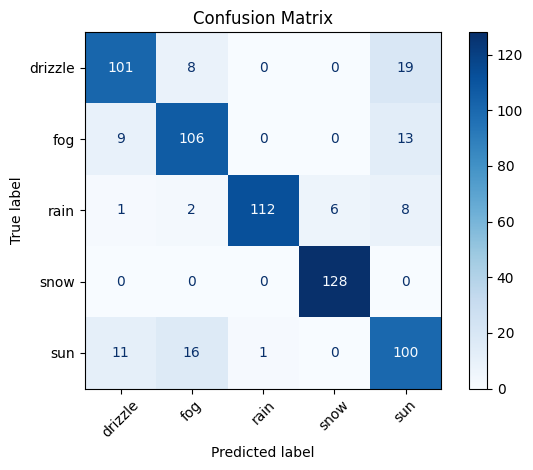


Predicted weather for new day: drizzle


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE  # Uncomment if using SMOTE

# 1. Load the dataset
df = pd.read_csv('seattle-weather.csv')

# 2. Encode weather labels into numeric form
le = LabelEncoder()
df['weather_label'] = le.fit_transform(df['weather'])

# 3. Select features and target
X = df[['precipitation', 'temp_max', 'temp_min', 'wind']]
y = df['weather_label']

# Optional: Handle class imbalance with SMOTE
smote = SMOTE(random_state=None)
X, y = smote.fit_resample(X, y)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=None, stratify=y
)

# 5. Train the Random Forest Classifier with class_weight
clf = RandomForestClassifier(n_estimators=100, random_state=None, class_weight='balanced')
clf.fit(X_train, y_train)

# 6. Predict and evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# 7. Confusion matrix plot
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=le.classes_, cmap='Blues', xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Predict on a new sample
new_day_df = pd.DataFrame(np.array([[0, 12.8, 5, 4.7]]),
                          columns=['precipitation', 'temp_max', 'temp_min', 'wind'])

predicted = clf.predict(new_day_df)
print("\nPredicted weather for new day:", le.inverse_transform(predicted)[0])

### Coorelation matrix of features

               precipitation  temp_max  temp_min      wind
precipitation       1.000000 -0.228555 -0.072684  0.328045
temp_max           -0.228555  1.000000  0.875687 -0.164857
temp_min           -0.072684  0.875687  1.000000 -0.074185
wind                0.328045 -0.164857 -0.074185  1.000000


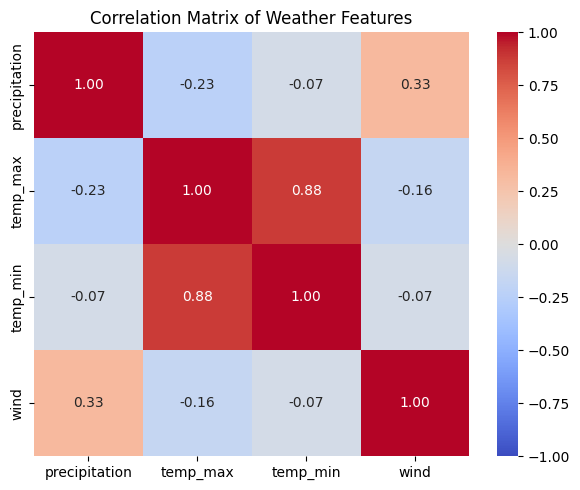

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = df[['precipitation', 'temp_max', 'temp_min', 'wind']].corr()

print(corr_matrix)

# Plot heatmap with fixed scale from -1 to 1
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Weather Features")
plt.tight_layout()
plt.show()

### Feature importances

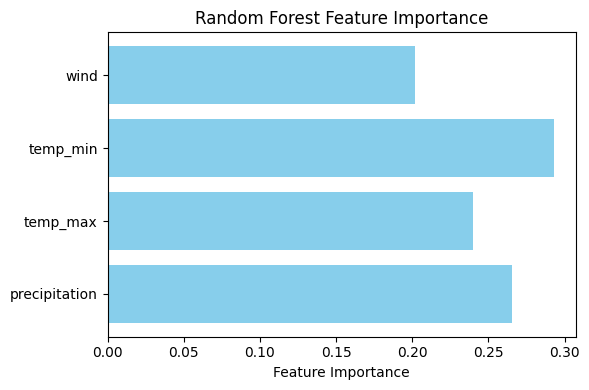

In [44]:
import matplotlib.pyplot as plt

importances = clf.feature_importances_
feature_names = X.columns

# Plot feature importance
plt.figure(figsize=(6, 4))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


### Coorrelation matrix without maximum temperature feature

               precipitation  temp_min      wind
precipitation       1.000000 -0.072684  0.328045
temp_min           -0.072684  1.000000 -0.074185
wind                0.328045 -0.074185  1.000000


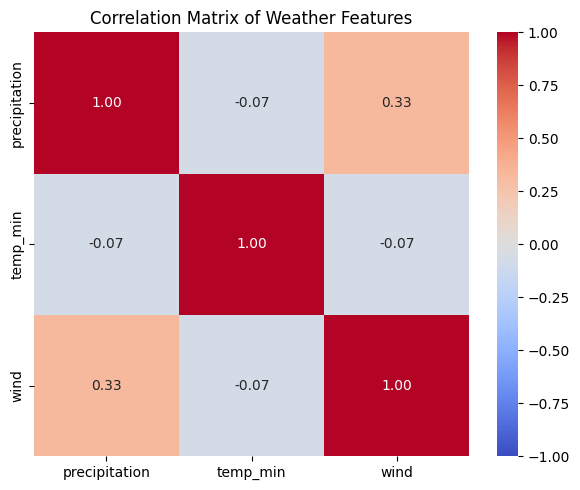

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = df[['precipitation', 'temp_min', 'wind']].corr()

print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Weather Features")
plt.tight_layout()
plt.show()

### Accuracy comparison using precipitation, wind, and minimum temperature or maximum temperature

Classification Report:

              precision    recall  f1-score   support

     drizzle       0.77      0.77      0.77       128
         fog       0.68      0.68      0.68       128
        rain       0.97      0.86      0.91       128
        snow       0.95      1.00      0.97       129
         sun       0.70      0.74      0.72       128

    accuracy                           0.81       641
   macro avg       0.81      0.81      0.81       641
weighted avg       0.81      0.81      0.81       641



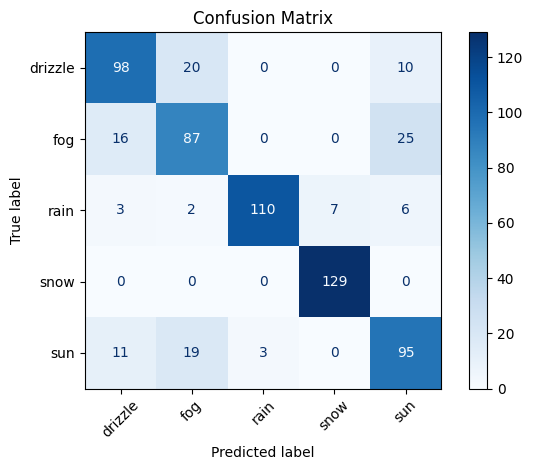

Classification Report:

              precision    recall  f1-score   support

     drizzle       0.76      0.73      0.75       128
         fog       0.68      0.78      0.72       129
        rain       0.94      0.88      0.91       128
        snow       0.94      0.98      0.96       128
         sun       0.70      0.65      0.67       128

    accuracy                           0.80       641
   macro avg       0.80      0.80      0.80       641
weighted avg       0.80      0.80      0.80       641



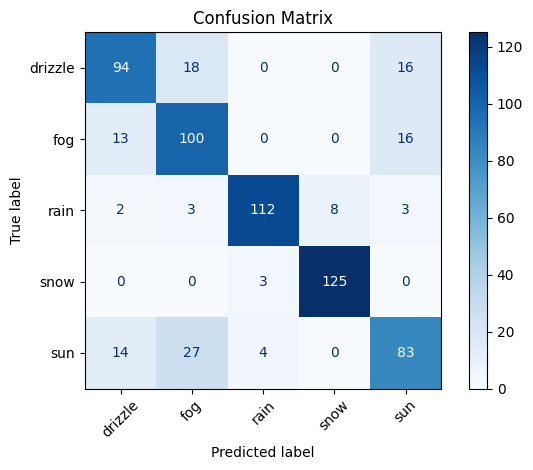

Accuracy with temp_min: 0.810
Accuracy with temp_max: 0.802


In [46]:
from sklearn.metrics import accuracy_score

# Model with temp_min
X1 = df[['precipitation', 'temp_min', 'wind']]
y1 = df['weather_label']
# Optional: Handle class imbalance with SMOTE
smote = SMOTE(random_state=None)
X1, y1 = smote.fit_resample(X1, y1)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, stratify=y1)
clf1 = RandomForestClassifier(n_estimators=100, class_weight='balanced')
clf1.fit(X1_train, y1_train)
y1_pred = clf1.predict(X1_test)
acc1 = accuracy_score(y1_test, y1_pred)
print("Classification Report:\n")
print(classification_report(y1_test, y1_pred, target_names=le.classes_, zero_division=0))
# 7. Confusion matrix plot
ConfusionMatrixDisplay.from_estimator(
    clf1, X1_test, y1_test, display_labels=le.classes_, cmap='Blues', xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Model with temp_max
X2 = df[['precipitation', 'temp_max', 'wind']]
y2 = df['weather_label']
# Optional: Handle class imbalance with SMOTE
smote = SMOTE(random_state=None)
X2, y2 = smote.fit_resample(X2, y2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2)
clf2 = RandomForestClassifier(n_estimators=100, class_weight='balanced')
clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)
acc2 = accuracy_score(y2_test, y2_pred)
print("Classification Report:\n")
print(classification_report(y2_test, y2_pred, target_names=le.classes_, zero_division=0))
# 7. Confusion matrix plot
ConfusionMatrixDisplay.from_estimator(
    clf2, X2_test, y2_test, display_labels=le.classes_, cmap='Blues', xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"Accuracy with temp_min: {acc1:.3f}")
print(f"Accuracy with temp_max: {acc2:.3f}")

### Feature importances of precipitation, minimum temperature, and wind features

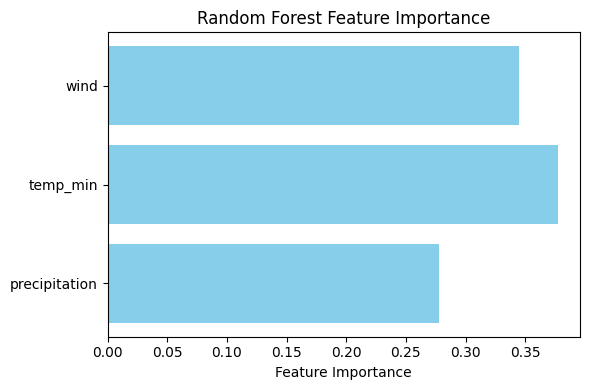

In [47]:
selected_features = ['precipitation', 'temp_min', 'wind']
X = df[selected_features]
y = df['weather_label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
clf.fit(X_train, y_train)

# Plot importance with correct shape
importances = clf.feature_importances_

plt.figure(figsize=(6, 4))
plt.barh(selected_features, importances, color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### Scatter plots

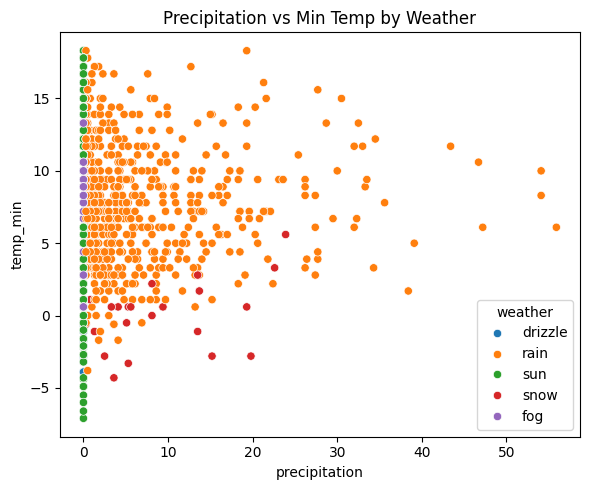

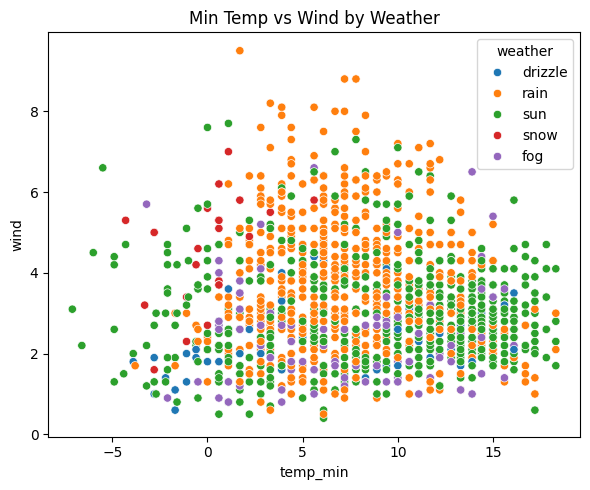

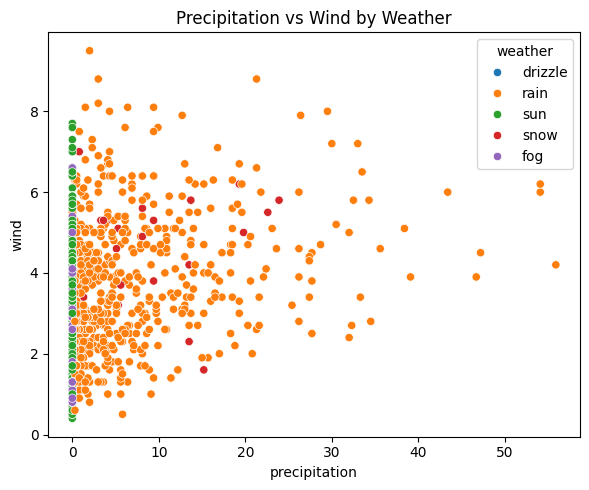

In [48]:
import seaborn as sns

# Add weather labels to the DataFrame (if not already)
df['weather_label'] = le.transform(df['weather'])

# Scatter plot: precipitation vs temp_max
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='precipitation', y='temp_min', hue='weather')
plt.title('Precipitation vs Min Temp by Weather')
plt.tight_layout()
plt.show()

# Scatter plot: temp_max vs wind
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='temp_min', y='wind', hue='weather')
plt.title('Min Temp vs Wind by Weather')
plt.tight_layout()
plt.show()

# Scatter plot: precipitation vs wind
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='precipitation', y='wind', hue='weather')
plt.title('Precipitation vs Wind by Weather')
plt.tight_layout()
plt.show()